<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. XGBoost Model for Crop Suitability Prediction

In this notebook we build an **XGBoost** classifier using the preprocessed data.
We will:
- Load the preprocessed training and test sets.
- Perform hyperparameter tuning with cross‑validation.
- Evaluate the best model on the test set.
- Plot the ROC curve and Precision‑Recall curve.
- Save the final model for later use.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, classification_report, confusion_matrix)
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

1. Load the Preprocessed Data

In [ ]:
# Load original data
df = pd.read_csv('Crop_training_data_FULL _1.csv')

# Separate features and target
X = df.drop(columns=['suitability', 'suitability_class', 'texture'])
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0})

# Load the preprocessor fitted in the previous notebook
preprocessor = joblib.load('models/preprocessor.pkl')

# Transform the data
X_processed = preprocessor.transform(X)

# Recreate the train/test split (using the same random_state as before)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1680, 31)
Test set size: (420, 31)


2. Baseline XGBoost

In [ ]:
xgb_default = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_default.fit(X_train, y_train)

y_pred_default = xgb_default.predict(X_test)
y_proba_default = xgb_default.predict_proba(X_test)[:, 1]

print("Default XGBoost Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall   :", recall_score(y_test, y_pred_default))
print("F1-score :", f1_score(y_test, y_pred_default))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_default))

Default XGBoost Performance:
Accuracy : 0.8476190476190476
Precision: 0.8128654970760234
Recall   : 0.8128654970760234
F1-score : 0.8128654970760234
ROC-AUC  : 0.9208999741656685


3. Hyperparameter Tuning with GridSearchCV

In [ ]:
# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)

# Set up GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation ROC-AUC: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation ROC-AUC: 0.9108


4. Evaluate Best Model on Test Set

In [ ]:
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print("Test Set Performance:")
print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall   : {:.4f}".format(recall_score(y_test, y_pred)))
print("F1-score : {:.4f}".format(f1_score(y_test, y_pred)))
print("ROC-AUC  : {:.4f}".format(roc_auc_score(y_test, y_proba)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Unsuitable', 'Suitable']))

Test Set Performance:
Accuracy : 0.8333
Precision: 0.8024
Recall   : 0.7836
F1-score : 0.7929
ROC-AUC  : 0.9097

Classification Report:
              precision    recall  f1-score   support

  Unsuitable       0.85      0.87      0.86       249
    Suitable       0.80      0.78      0.79       171

    accuracy                           0.83       420
   macro avg       0.83      0.83      0.83       420
weighted avg       0.83      0.83      0.83       420



5. Confusion Matrix

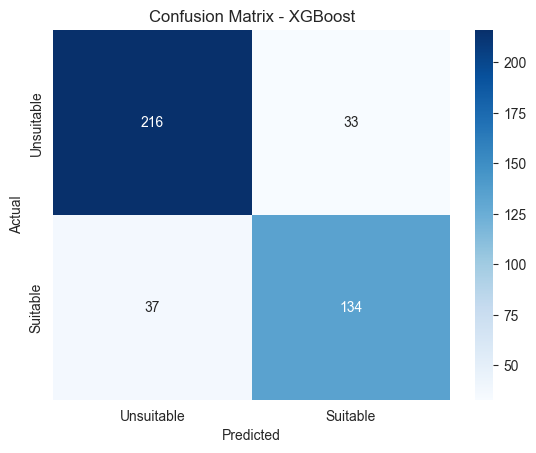

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unsuitable', 'Suitable'],
            yticklabels=['Unsuitable', 'Suitable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

6. ROC Curve

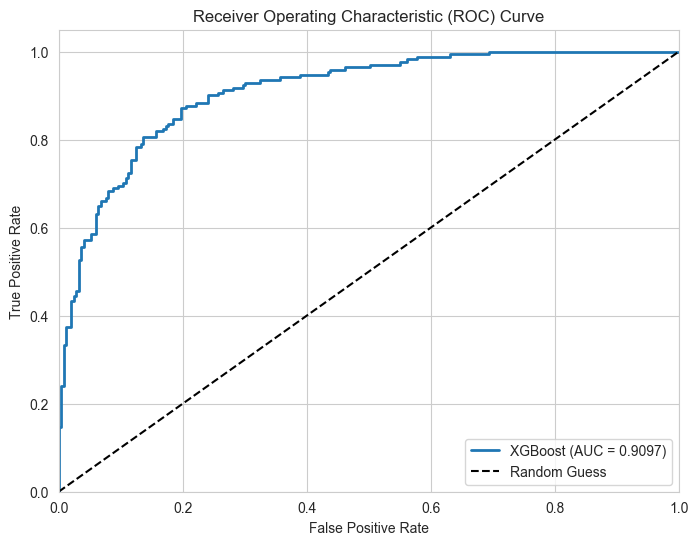

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

7. Precision‑Recall Curve


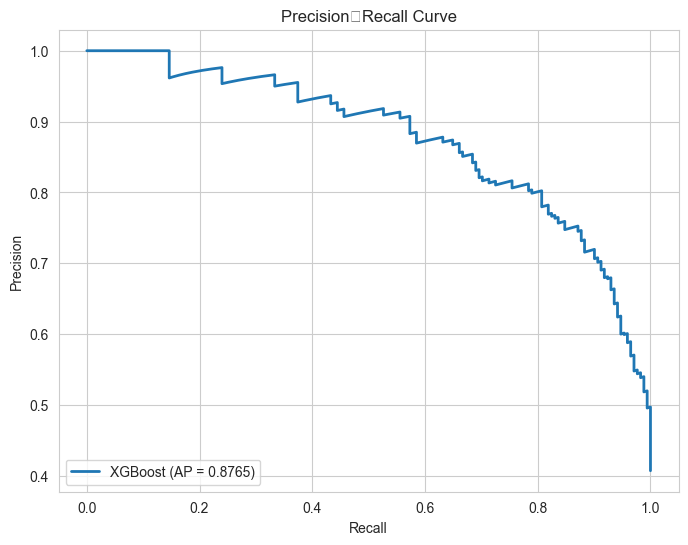

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'XGBoost (AP = {ap:.4f})', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

8. Feature Importance

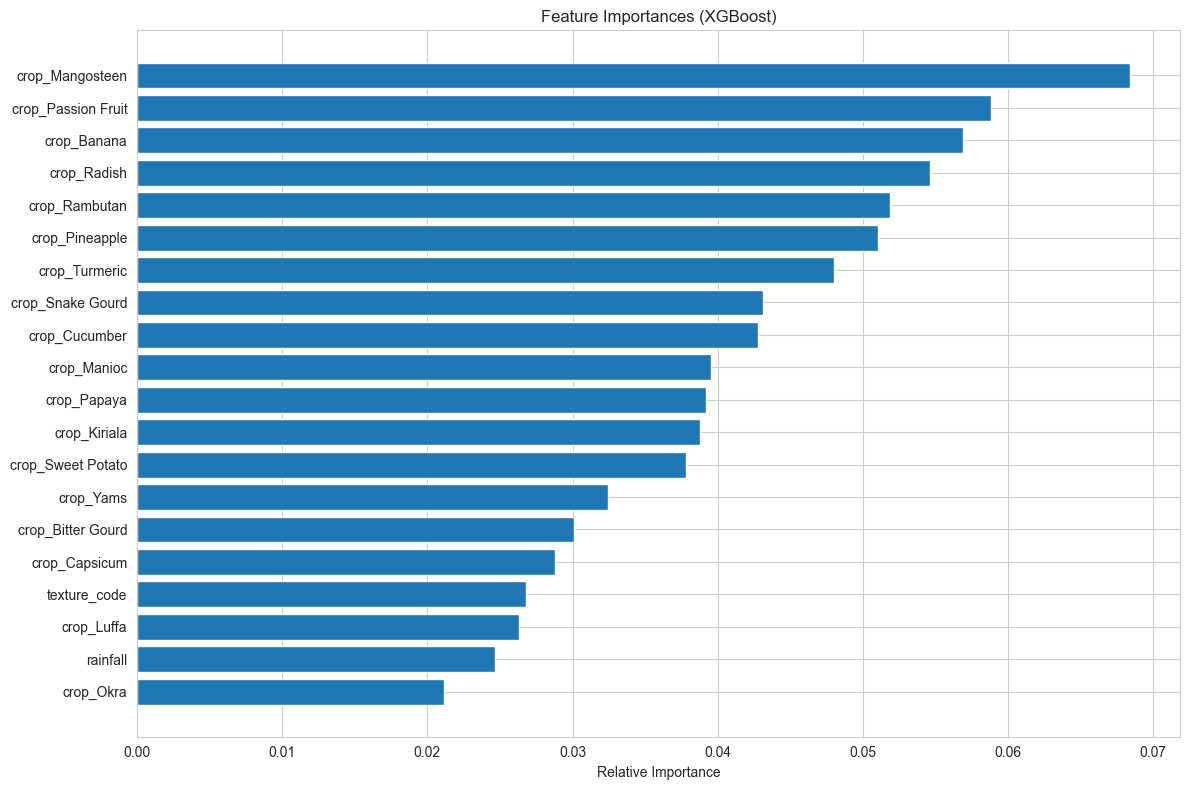

In [ ]:
# Get feature names after preprocessing
num_features = ['temperature', 'rainfall', 'sunshine_hours', 'ph',
                'organic_carbon', 'cec', 'awc', 'bulk_density',
                'rooting_depth_m', 'texture_code']
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(['crop'])
all_features = np.concatenate([num_features, cat_features])

importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importances (XGBoost)")
plt.barh(range(20), importances[indices][:20], align='center')
plt.yticks(range(20), all_features[indices][:20])
plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

9. Save the Best Model

In [ ]:
# Save the trained XGBoost model
joblib.dump(best_xgb, 'models/xgboost_best.pkl')
print("Model saved to ../models/xgboost_best.pkl")

Model saved to ../models/xgboost_best.pkl
